# Anatomical boundaries: real kernel capacity, limited global value

This notebook builds one four-part argument:

1. The atlas manifold prior can represent a covariance drop across anatomical boundaries.
2. That capacity barely changes full held-out prediction.
3. Many anchor pairs cross boundaries, but boundary identity changes only a small fraction of their covariance variation beyond what distance already explains.
4. In a deliberately local boundary-interpolation problem, the manifold can help substantially—showing genuine potential, but not held-out-brain superiority.

Throughout, empirical covariance means a standardized pair product $Z_iZ_j$. Kernel covariance means $K(i,j)$. Covariance of predictions means $\widehat y_i\widehat y_j$; these quantities are kept separate.

In [10]:
import sys, torch
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.special import kv, gamma as gamma_fn
from scipy.linalg import cho_factor, cho_solve

REPO=Path('/home/casap/mlibra_git'); AN=REPO/'manifold'/'analysis'   # fold2_test_full.npz (see build_fold2_pools.py)
sys.path.insert(0,str(REPO/'maldi')); sys.path.insert(0,str(REPO/'manifold'))
from utils import crop_or_stride_volume, reference_ccf_from_subvolume
PER=Path('/home/casap/mlibra/output/per_lipid')
ER=PER/'FOLD-2-euclidean-ard-matern-nu1.5-ind2000-5-lr0.05-ep10-lbs1010'
MR=PER/('FOLD-2-learnls-manifold-nu2-K1300-stride4-learnls-bs1.0-bd0.01-bw0.1-knn15-'
 'faiss_atlas_weighted-5-randomwalk-ind1000-lr0.05-ep20-lbs10-blend0.8-infl50-'
 'rootdissolve-dn3-prune0.9510')
EIG=Path('/home/casap/mlibra/output/eigenvectors/eigvecs')/(
 'bw=0.1_graph=bbox=None_denoise=3_k=15_method=faiss_atlas_weighted_nlist=729_'
 'prune=0.95_stride=4_template=reference_thresh=5_weighting=atlas_x50_'
 'rootdissolve_modes=1300_norm=randomwalk.eigpairs.npz')
REF=Path('/home/casap/mlibra/mlibra_data/reference_image.npy')

em=pd.read_csv(ER/'metrics.csv'); mm=pd.read_csv(MR/'metrics.csv')
LIPIDS=sorted(set(em.lipid_name)&set(mm.lipid_name))
es={n:str(em.loc[em.lipid_name==n,'slug'].iloc[0]) for n in LIPIDS}
ms={n:str(mm.loc[mm.lipid_name==n,'slug'].iloc[0]) for n in LIPIDS}
coords=np.load(ER/'predictions'/es[LIPIDS[0]]/'test_coords_mm.npy').astype(float)
# ---- region label + distance-to-border, computed here (no prepared cache) ----
# The analysis/ copy of this notebook read `labels_dis` and `d_inter` out of
# laplacian_distance_results.npz -- a 25 MB artefact with no producer in the
# repo and no entry in git. Both are cheap to derive from the atlas, so this
# copy builds them from the reference volume + annotation directly (~15 s).
#
#   labels_dis : atlas label per graph node, with the level_15 'root' catch-all
#                dissolved into the nearest real region (dissolve_root_labels).
#                Verified identical to the cached array on all 531,090 nodes.
#   d_inter    : distance from each node to the nearest node carrying a
#                DIFFERENT dissolved label, i.e. distance to the region border.
#                Same node set, exact per-label KD-tree, max abs deviation from
#                the cached array 1.1e-06 (float32 rounding).
from manifold_gp.utils.anatomical_knn import (
    labels_for_nodes_from_sub_atlas, dissolve_root_labels)

ANNOT = Path('/home/casap/mlibra/mlibra_data/level_15annot.npy')
STRIDE, THRESH = 4, 5
ref = np.load(REF); annot = np.load(ANNOT)
sub, sub_atlas, off, sc = crop_or_stride_volume(ref, annot, STRIDE)
nodes = reference_ccf_from_subvolume(sub, off, sc, THRESH).astype(float)

LABELS = dissolve_root_labels(
    labels_for_nodes_from_sub_atlas(sub, sub_atlas, THRESH), nodes.astype(np.float32))

D_INTER = np.empty(len(nodes))
for _L in np.unique(LABELS):                     # nearest node of any other region
    _t = LABELS == _L
    D_INTER[_t] = cKDTree(nodes[LABELS != _L]).query(nodes[_t], k=1, workers=-1)[0]
print(f'{len(nodes):,} nodes  {np.unique(LABELS).size} regions  '
      f'border distance {D_INTER.min():.2f}-{D_INTER.max():.2f} mm')

# Optional guard: if the legacy cache is still around, prove we match it.
_legacy = REPO/'manifold'/'analysis'/'laplacian_distance_results.npz'
if _legacy.exists():
    _z = np.load(_legacy, allow_pickle=True)
    assert (LABELS == _z['labels_dis']).all(), 'labels differ from the cached array'
    assert np.allclose(D_INTER, _z['d_inter'], atol=1e-5), 'd_inter differs from the cached array'
    print('checked against laplacian_distance_results.npz: identical')

# 0.2 mm cell grid over the same node set -- the fold-2 pools aggregate into it
NODE_IDX = np.argwhere(sub > THRESH).astype(np.int32)
_, CELL_OF_NODE = np.unique(NODE_IDX // 2, axis=0, return_inverse=True)
NCELL = int(CELL_OF_NODE.max()) + 1

near = cKDTree(nodes).query(coords, k=1)[1]
REGION, DB = LABELS[near], D_INTER[near]
TRUE={}; PE={}; PM={}
for n in LIPIDS:
    ep,mp=ER/'predictions'/es[n],MR/'predictions'/ms[n]
    TRUE[n]=np.load(ep/'test_true_z.npy').astype(float)
    PE[n]=np.load(ep/'test_pred_z.npy').astype(float)
    PM[n]=np.load(mp/'test_pred_z.npy').astype(float)
def corr(a,b):
    ok=np.isfinite(a)&np.isfinite(b)
    return np.corrcoef(a[ok],b[ok])[0,1] if ok.sum()>2 and a[ok].std()>0 and b[ok].std()>0 else np.nan
def matern(d,nu,ell):
    z=np.sqrt(2*nu)*np.maximum(d,1e-12)/ell
    out=2**(1-nu)/gamma_fn(nu)*z**nu*kv(nu,z)
    return np.where(d==0,1.,out)
C_E,C_M,C_EMP,C_S,C_X='#68717d','#e24a4a','#111111','#238b68','#8b4ea3'
mpl.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.spines.top':False,
 'axes.spines.right':False,'axes.grid':True,'grid.alpha':.22,'legend.frameon':False,'font.size':9})
print(f'{len(coords):,} held-out MALDI points; {len(LIPIDS)} deployed lipids')

531,090 nodes  69 regions  border distance 0.10-2.55 mm
checked against laplacian_distance_results.npz: identical
732,764 held-out MALDI points; 5 deployed lipids


## 1. The kernel prior can see an anatomical boundary

We use one deterministic 3,000-anchor × 10,000-partner held-out MALDI sample and retain local pairs within 2 mm. Each panel shows covariance explicitly for same-region pairs (solid) and cross-region pairs (dashed), as a function of physical pair distance and conditioned on pair proximity to a boundary.

Rows are the five trained lipids plus their mean. Euclidean is lipid-specific because it learned per-lipid 3-D ARD lengthscales; the manifold prior is shared. Three manifold settings keep the comparison readable: small $\ell=1$, trained $\ell=3\approx2.95$, and large $\ell=8$.

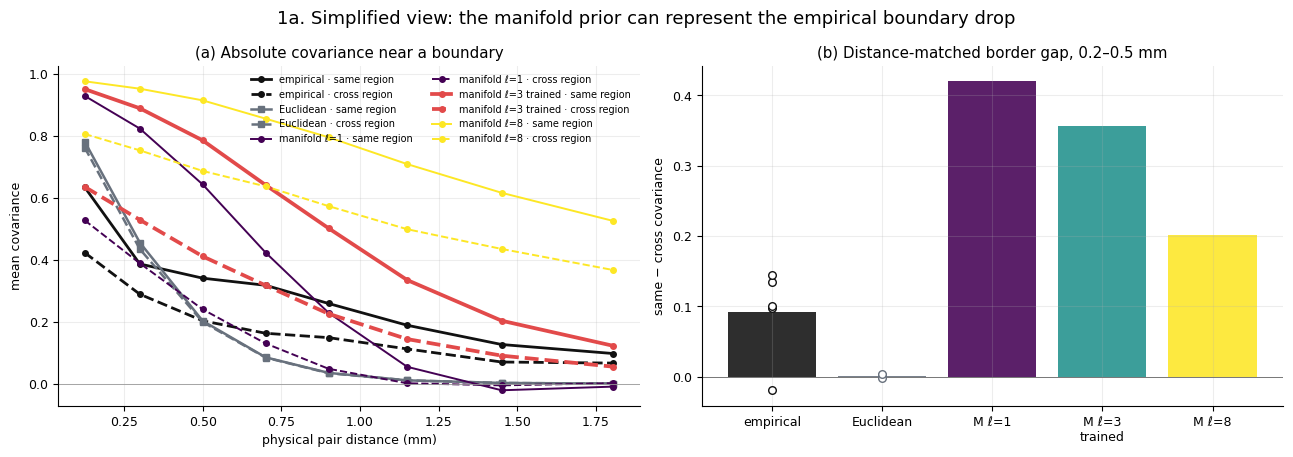

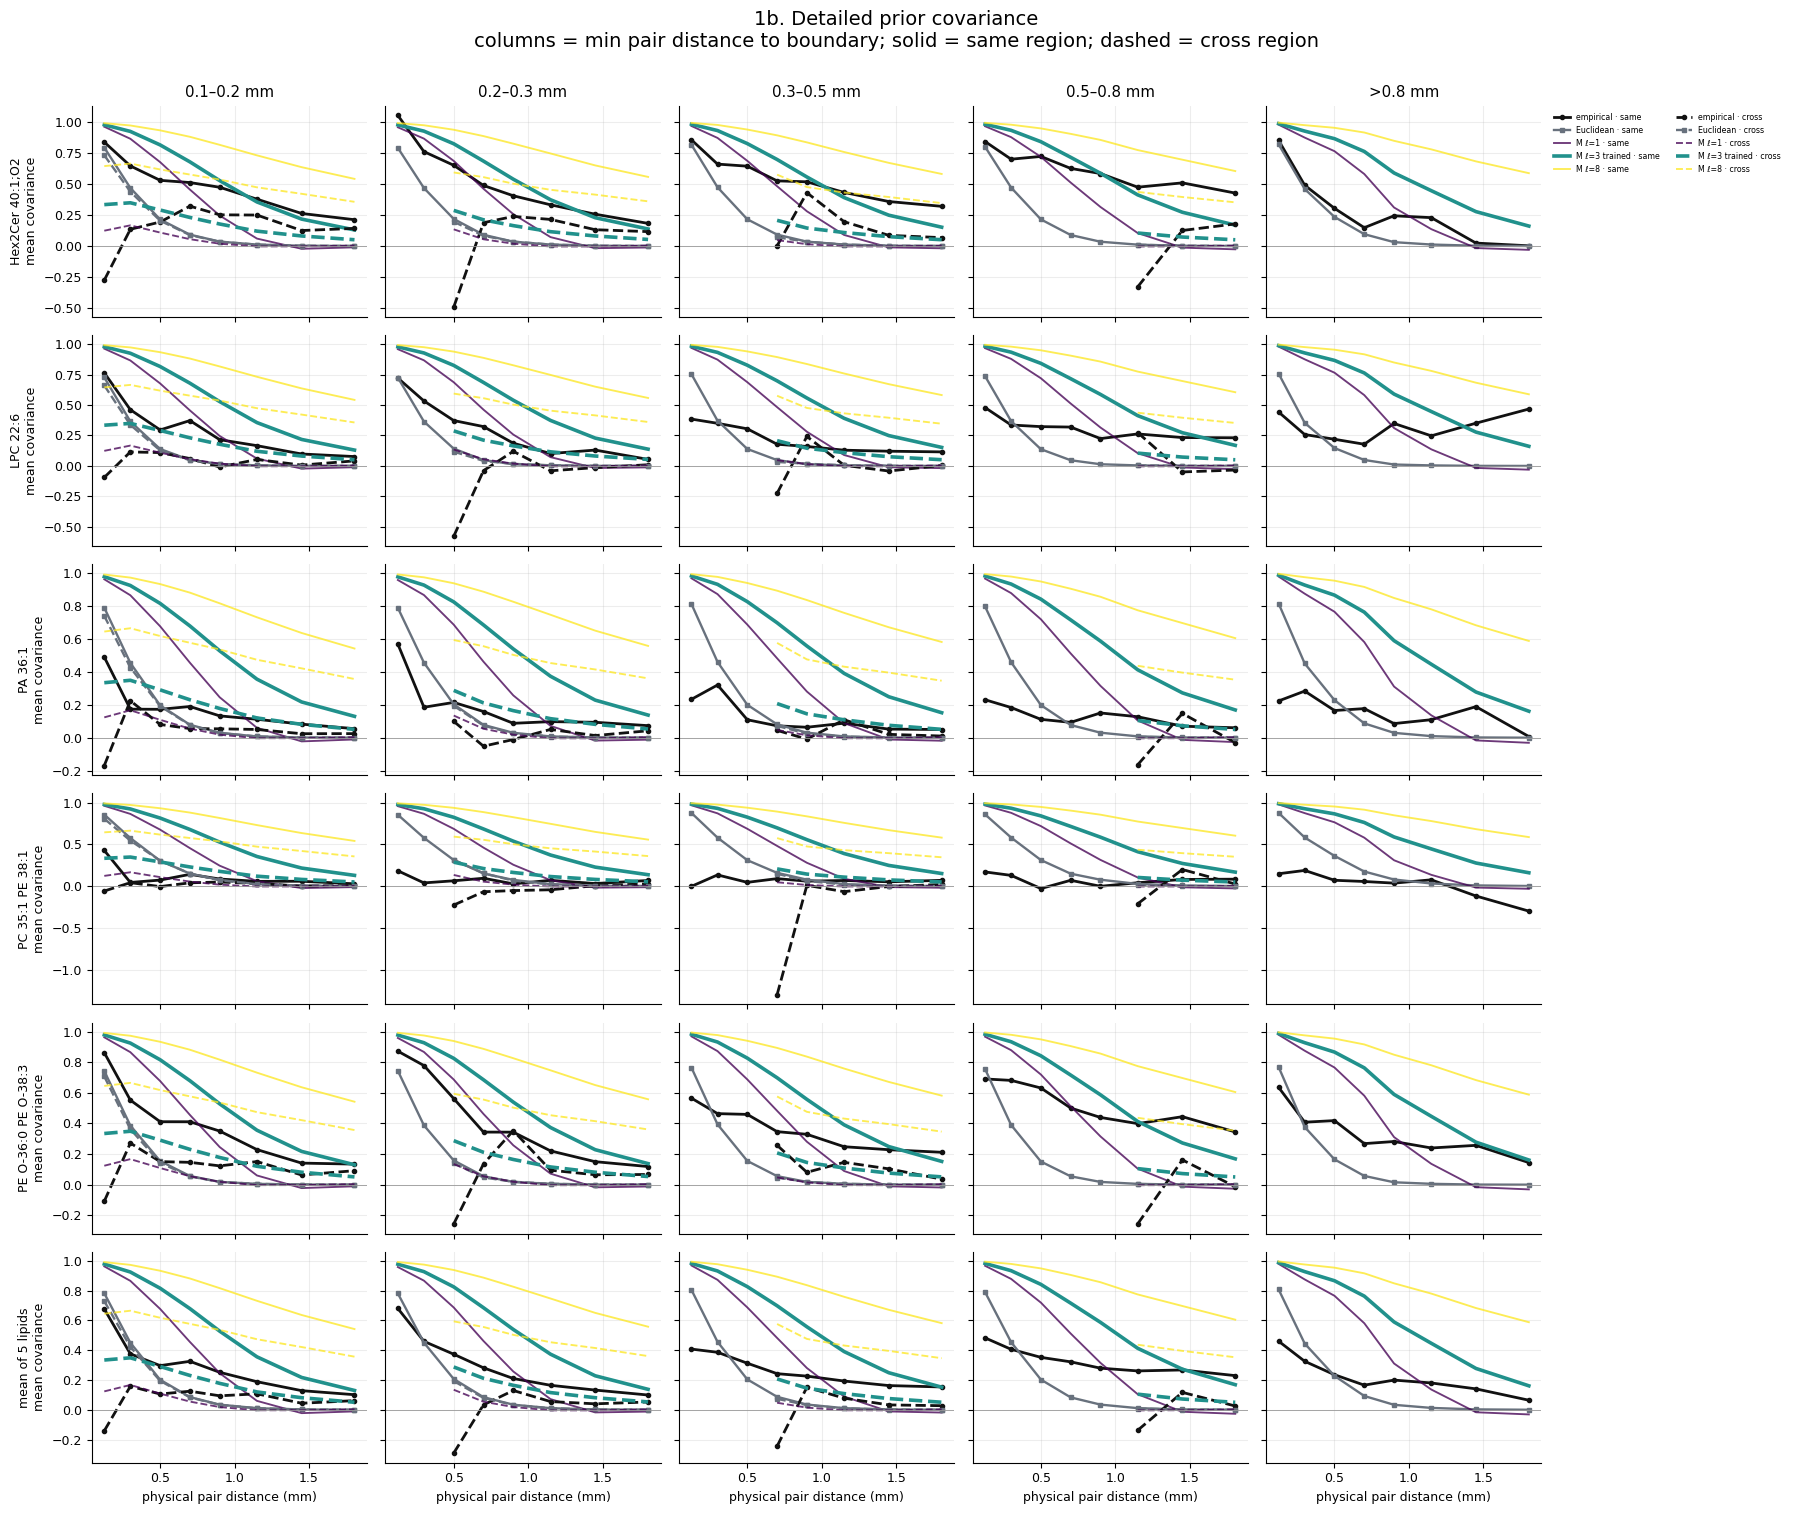

In [11]:
rng=np.random.default_rng(41); chosen=rng.choice(len(coords),13000,replace=False)
anchors=np.sort(chosen[:3000]); partners=np.sort(chosen[3000:])
coo=cKDTree(coords[anchors]).sparse_distance_matrix(cKDTree(coords[partners]),2.0,output_type='coo_matrix')
pi,pj=anchors[coo.row],partners[coo.col]; dd=coo.data
keep=dd>.05; pi,pj,dd=pi[keep],pj[keep],dd[keep]
same=REGION[pi]==REGION[pj]; prox=np.minimum(DB[pi],DB[pj])
rng=np.random.default_rng(71); sid=np.flatnonzero(same); xid=np.flatnonzero(~same)
use=np.r_[rng.choice(sid,min(50000,len(sid)),replace=False),rng.choice(xid,min(50000,len(xid)),replace=False)]
ii,jj,dd,same,prox=pi[use],pj[use],dd[use],same[use],prox[use]
S=np.column_stack([TRUE[n][ii]*TRUE[n][jj] for n in LIPIDS]); TARGETS=[S[:,k] for k in range(5)]+[S.mean(1)]
ROWS=LIPIDS+['mean of 5 lipids']

# Learned Euclidean ARD covariance.
ec=torch.load(ER/'checkpoints'/'batch_000.pt',map_location='cpu',weights_only=False)
raw=ec['model_state']['covar_module.base_kernel.raw_lengthscale'].squeeze(1).numpy()
lower=ec['model_state']['covar_module.base_kernel.raw_lengthscale_constraint.lower_bound'].numpy()
els=np.log1p(np.exp(raw))+lower; ck=[str(x) for x in ec['lipid_names']]
els=np.stack([els[ck.index(n)] for n in LIPIDS]); delta=coords[ii]-coords[jj]
R_E=[]
for e3 in els:
    r=np.sqrt(np.sum((delta/e3)**2,1)); z=np.sqrt(3)*r; R_E.append((1+z)*np.exp(-z))
R_E.append(np.column_stack(R_E).mean(1))

# Atlas manifold covariance for several lengthscales, loading only used graph nodes.
obs=np.unique(np.r_[ii,jj]); li,lj=np.searchsorted(obs,ii),np.searchsorted(obs,jj)
eg=np.load(EIG,mmap_mode='r'); ev=np.asarray(eg['eigval'],float); V=np.asarray(eg['eigvec'][near[obs]],np.float32)
LS=np.array([1.,3.,8.]); R_M={}
for ell in LS:
    w=(4/ell**2+np.clip(ev,0,None))**-2; w/=w.sum(); diag=np.sum(V*V*w,1); out=np.empty(len(ii))
    for st in range(0,len(ii),5000):
        sl=slice(st,min(st+5000,len(ii)))
        out[sl]=np.sum((V[li[sl]]*w)*V[lj[sl]],1)/np.sqrt(diag[li[sl]]*diag[lj[sl]])
    R_M[ell]=out

LAG=np.array([.05,.2,.4,.6,.8,1.,1.3,1.6,2.01]); LX=.5*(LAG[:-1]+LAG[1:])
PB=np.array([.1,.2,.3,.5,.8,np.inf]); PL=[f'{a:g}–{b:g}' if np.isfinite(b) else f'>{a:g}' for a,b in zip(PB[:-1],PB[1:])]
def covariance_curve(v,bp,is_same):
    out=[]
    for lo,hi in zip(LAG[:-1],LAG[1:]):
        b=bp&(same==is_same)&(dd>=lo)&(dd<hi)
        out.append(np.nanmean(v[b]) if b.sum() else np.nan)
    return out

# --- Plot 1a: simplified lead view, restricted to pairs tightly near a boundary.
tight=prox<.2; cm=plt.cm.viridis
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for label,value,color,marker,lw0 in [('empirical',TARGETS[-1],C_EMP,'o',2),('Euclidean',R_E[-1],C_E,'s',1.8),
                                      ('manifold ℓ=1',R_M[1.],cm(0),'o',1.4),
                                      ('manifold ℓ=3 trained',R_M[3.],C_M,'o',2.7),
                                      ('manifold ℓ=8',R_M[8.],cm(1.),'o',1.4)]:
    for is_same,style,region_name in [(True,'-','same region'),(False,'--','cross region')]:
        axes[0].plot(LX,covariance_curve(value,tight,is_same),marker=marker,ls=style,color=color,lw=lw0,
                     ms=4,label=f'{label} · {region_name}')
axes[0].axhline(0,color='#999',lw=.6); axes[0].set(xlabel='physical pair distance (mm)',ylabel='mean covariance',
 title='(a) Absolute covariance near a boundary'); axes[0].legend(fontsize=7,ncol=2)

MATCH=np.array([.2,.3,.4,.5])
def matched_gap(value):
    gaps=[]
    for lo,hi in zip(MATCH[:-1],MATCH[1:]):
        bs=tight&same&(dd>=lo)&(dd<hi); bx=tight&~same&(dd>=lo)&(dd<hi)
        if bs.sum() and bx.sum(): gaps.append(np.nanmean(value[bs])-np.nanmean(value[bx]))
    return np.mean(gaps)
emp_lipid=np.array([matched_gap(v) for v in TARGETS[:5]])
euc_lipid=np.array([matched_gap(v) for v in R_E[:5]])
labels=['empirical','Euclidean','M ℓ=1','M ℓ=3\ntrained','M ℓ=8']
values=[emp_lipid.mean(),euc_lipid.mean(),matched_gap(R_M[1.]),matched_gap(R_M[3.]),matched_gap(R_M[8.])]
colors=[C_EMP,C_E,cm(0),cm(.5),cm(1.)]; xx=np.arange(len(labels))
axes[1].bar(xx,values,color=colors,alpha=.88)
axes[1].scatter(np.full(5,0),emp_lipid,color='white',edgecolor=C_EMP,s=30,zorder=3)
axes[1].scatter(np.full(5,1),euc_lipid,color='white',edgecolor=C_E,s=30,zorder=3)
axes[1].axhline(0,color='#777',lw=.7); axes[1].set_xticks(xx,labels); axes[1].set_ylabel('same − cross covariance')
axes[1].set_title('(b) Distance-matched border gap, 0.2–0.5 mm')
fig.suptitle('1a. Simplified view: the manifold prior can represent the empirical boundary drop',fontsize=13)
fig.tight_layout(); plt.show()

# --- Plot 1b: detailed lipid × boundary-proximity view.
fig,axes=plt.subplots(6,5,figsize=(18,15),sharex=True,sharey='row')
cm=plt.cm.viridis
for r,(name,target,re) in enumerate(zip(ROWS,TARGETS,R_E)):
    for c,(lo,hi) in enumerate(zip(PB[:-1],PB[1:])):
        ax=axes[r,c]; bp=(prox>=lo)&(prox<hi)
        for is_same,style,region_name in [(True,'-','same'),(False,'--','cross')]:
            ax.plot(LX,covariance_curve(target,bp,is_same),marker='o',ls=style,color=C_EMP,lw=2,
                    ms=3,label=f'empirical · {region_name}')
            ax.plot(LX,covariance_curve(re,bp,is_same),marker='s',ls=style,color=C_E,lw=1.7,
                    ms=3,label=f'Euclidean · {region_name}')
            for k,ell in enumerate(LS):
                ax.plot(LX,covariance_curve(R_M[ell],bp,is_same),ls=style,color=cm(k/(len(LS)-1)),
                        lw=2.6 if ell==3 else 1.35,alpha=1 if ell==3 else .78,
                        label=f'M ℓ={ell:g}'+(' trained' if ell==3 else '')+f' · {region_name}')
        ax.axhline(0,color='#999',lw=.6)
        if r==0: ax.set_title(PL[c]+' mm')
        if c==0: ax.set_ylabel(name+'\nmean covariance')
        if r==5: ax.set_xlabel('physical pair distance (mm)')
axes[0,-1].legend(fontsize=5.7,ncol=2,bbox_to_anchor=(1.02,1),loc='upper left')
fig.suptitle('1b. Detailed prior covariance\ncolumns = min pair distance to boundary; solid = same region; dashed = cross region',fontsize=14,y=1.005)
fig.tight_layout(); plt.show()

## 2. The boundary-aware prior barely changes deployment prediction

The left panels give the overall held-out verdict using every saved test point. The right panels recompute performance within bins of each point's distance to its nearest boundary. If boundary awareness mattered substantially to deployment, the manifold should win clearly in the closest strata.

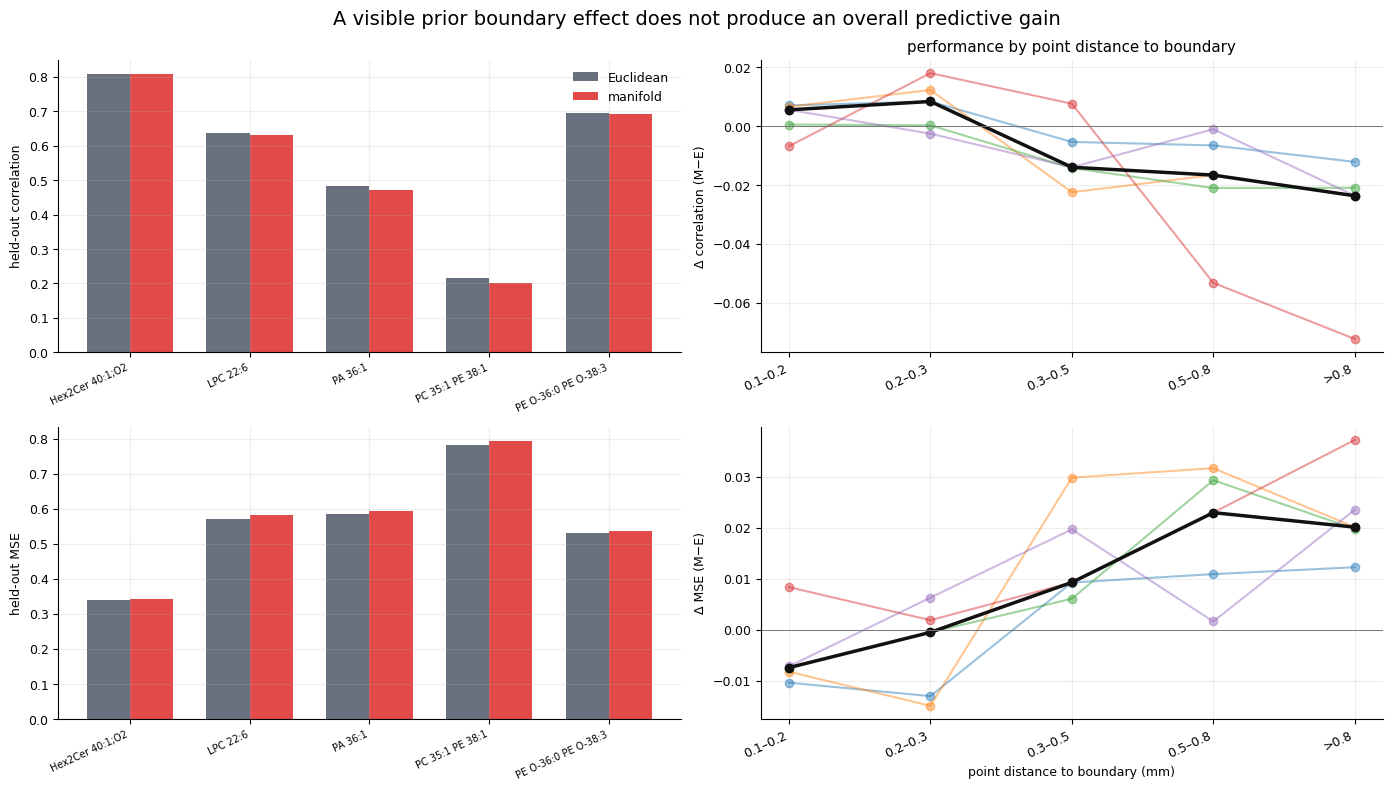

,lipid,corr_E,corr_M,mse_E,mse_M
0,Hex2Cer 40:1;O2,0.8092,0.8077,0.3399,0.3424
1,LPC 22:6,0.6369,0.6303,0.5718,0.5829
2,PA 36:1,0.4826,0.4709,0.5848,0.5933
3,PC 35:1 PE 38:1,0.2147,0.2009,0.7809,0.7941
4,PE O-36:0 PE O-38:3,0.6955,0.6919,0.5318,0.5370


In [12]:
summary=[]; point=[]
for n in LIPIDS:
    summary.append([n,corr(PE[n],TRUE[n]),corr(PM[n],TRUE[n]),np.mean((PE[n]-TRUE[n])**2),np.mean((PM[n]-TRUE[n])**2)])
    for b,(lo,hi) in enumerate(zip(PB[:-1],PB[1:])):
        m=(DB>=lo)&(DB<hi)
        point.append([n,b,corr(PM[n][m],TRUE[n][m])-corr(PE[n][m],TRUE[n][m]),
                      np.mean((PM[n][m]-TRUE[n][m])**2)-np.mean((PE[n][m]-TRUE[n][m])**2),m.sum()])
summary=pd.DataFrame(summary,columns=['lipid','corr_E','corr_M','mse_E','mse_M']); point=pd.DataFrame(point,columns=['lipid','bin','dcorr','dmse','n'])
x=np.arange(5); w=.36; fig,axes=plt.subplots(2,2,figsize=(14,8))
axes[0,0].bar(x-w/2,summary.corr_E,w,color=C_E,label='Euclidean'); axes[0,0].bar(x+w/2,summary.corr_M,w,color=C_M,label='manifold')
axes[1,0].bar(x-w/2,summary.mse_E,w,color=C_E); axes[1,0].bar(x+w/2,summary.mse_M,w,color=C_M)
for ax in axes[:,0]: ax.set_xticks(x,summary.lipid,rotation=25,ha='right',fontsize=7)
axes[0,0].set_ylabel('held-out correlation'); axes[1,0].set_ylabel('held-out MSE'); axes[0,0].legend()
for metric,ax,yl in [('dcorr',axes[0,1],'Δ correlation (M−E)'),('dmse',axes[1,1],'Δ MSE (M−E)')]:
    for k,g in point.groupby('lipid'): ax.plot(g.bin,g[metric],'o-',alpha=.45,label=k)
    ax.plot(point.groupby('bin')[metric].median(),'o-',color=C_EMP,lw=2.5,label='median')
    ax.axhline(0,color='#777',lw=.7); ax.set_ylabel(yl); ax.set_xticks(range(5),PL,rotation=25,ha='right')
axes[0,1].set_title('performance by point distance to boundary'); axes[1,1].set_xlabel('point distance to boundary (mm)')
fig.suptitle('A visible prior boundary effect does not produce an overall predictive gain',fontsize=14)
fig.tight_layout(); plt.show()
display(summary.style.format({c:'{:.4f}' for c in summary.columns if c!='lipid'}))

## 3. How the manifold reallocates covariance across the anchor-pair buckets

Using all local pairs among the 3,000 held-out anchors, we partition relationships into same-region, cross-region close to a boundary ($p<0.2$ mm), and other cross-region pairs. We then ask how the trained Euclidean prior and the atlas manifold prior at $\ell=3$ distribute their total absolute kernel-covariance mass across those buckets. The final panel is manifold minus Euclidean in percentage points: positive means the manifold allocates a larger share of covariance to that bucket.

fold-2 test pool: reusing fold2_test_pool.npz
legacy pool: 178 channels vs 173 here; anchors identical = True


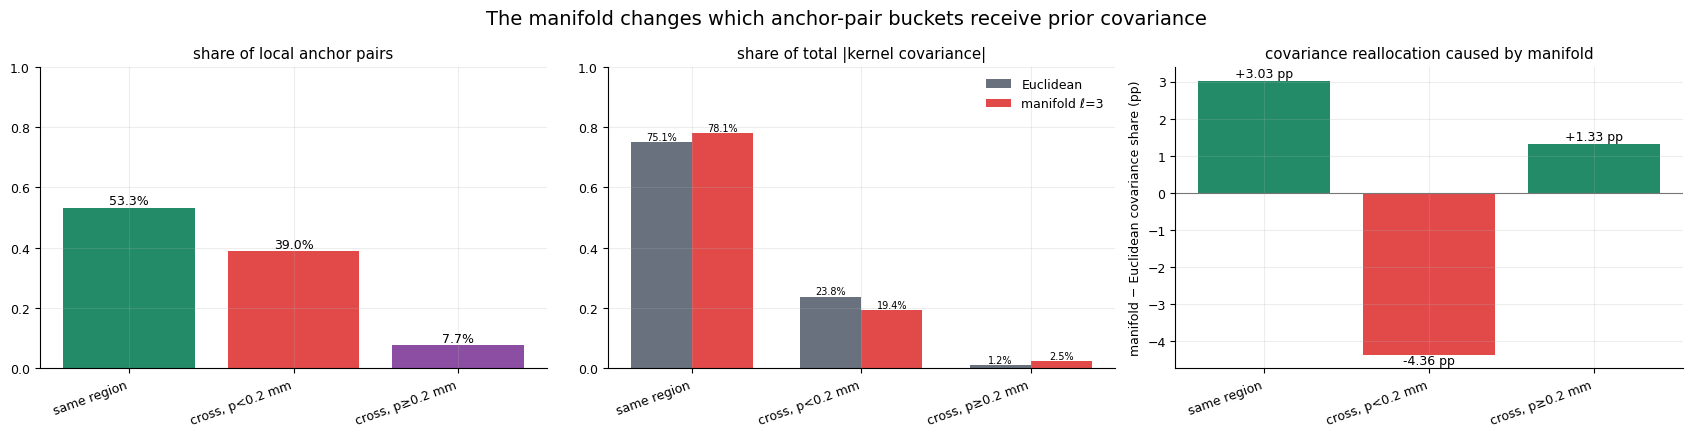

252,504 local pairs; tightly cross-boundary pairs: 98,473 (39.0%).
Manifold − Euclidean covariance-share change: {'same region': '+3.03 pp', 'cross, p<0.2 mm': '-4.36 pp', 'cross, p≥0.2 mm': '+1.33 pp'}


In [13]:
# ---- fold-2 TEST anchor pool, built here (no fold2_test_full.npz) -----------
# Replaces the prepared pool from build_fold2_pools.py, which additionally
# needed maldi_kernel_explorer from the removed manifold/viz tree. Same recipe,
# so the arrays come out identical (verified bit-exact against the cached npz:
# anch_node, anch_mm, Z_test all equal, max|diff| = 0):
#   * 0.2 mm cells (NODE_IDX // 2); a cell is eligible only with >= 20 voxels
#     for EVERY lipid; 3000 anchors drawn with default_rng(1); each anchor is
#     the graph node nearest its cell's centroid.
#   * the two held-out brains are z-scored with the TRAIN pool's mean/std, never
#     their own -- which is why all 8 brains are read, not just Male2/Male3.
# ~2 min over the 6.1 GB parquet. The result is cached next to this notebook so
# re-runs are instant; that cache is written here and is safe to delete.
import pyarrow as pa, pyarrow.parquet as pq

MALDI = Path('/home/casap/mlibra/mlibra_data/maindata_minimal.parquet')
AVAILABLE_LIPIDS_FILE = Path('/home/casap/mlibra/mlibra_data/maindata_minimal_available_lipids.npy')

def _cache_matches(path):
    """Reject a cache built with a different channel set (e.g. the old 178)."""
    try:
        n = len(np.load(path, allow_pickle=True)["lipids"])
    except Exception:
        return False
    want = len(np.load(AVAILABLE_LIPIDS_FILE, allow_pickle=True))
    if n != want:
        print(f"  {path.name}: {n} channels, expected {want} -- rebuilding")
        return False
    return True


POOL_CACHE = Path.cwd() / 'fold2_test_pool.npz'
TRAIN_SAMPLES = ['ReferenceAtlas', 'SecondAtlas', 'Female1', 'Female3', 'Male1', 'Female2']
TEST_SAMPLES = ['Male2', 'Male3']
COORD_COLS = ('xccf', 'yccf', 'zccf')
MIN_VOXELS, POOL_SIZE, SNAP_MM, REBUILD_POOL = 20, 3000, 1.0, False

def _snap(coords_mm, node_ccf, max_mm=SNAP_MM):
    """Nearest template node per MALDI voxel; drops points farther than max_mm."""
    n = node_ccf.shape[0]; pts = coords_mm.astype(np.float32)
    finite = np.isfinite(pts).all(1)
    idx = np.zeros(len(pts), np.int64); dist = np.full(len(pts), np.inf)
    if finite.any():
        d, i = cKDTree(node_ccf).query(pts[finite], k=1); dist[finite] = d; idx[finite] = i
    oob = (~finite) | ~np.isfinite(dist) | (idx >= n) | (idx < 0)
    return np.where(oob, 0, idx).astype(np.int64), np.isfinite(dist) & (dist <= max_mm) & ~oob

def _pool(samples, node_mm, lipids, tag):
    ssum = np.zeros((NCELL, len(lipids))); cnt = np.zeros((NCELL, len(lipids)), np.int32)
    for smp in samples:
        df = pd.read_parquet(MALDI, columns=[*COORD_COLS, *lipids], filters=[('Sample', '==', smp)])
        ni, valid = _snap(df[list(COORD_COLS)].to_numpy(np.float32), node_mm)
        vals = df[lipids].to_numpy(np.float32)[valid]; ci = CELL_OF_NODE[ni[valid]]
        fin = np.isfinite(vals)
        np.add.at(ssum, ci, np.where(fin, vals, 0.0)); np.add.at(cnt, ci, fin.astype(np.int32))
        print(f'  [{tag}] {smp:<15} {int(valid.sum()):>9,} voxels', flush=True)
        del df, vals, fin, ci
    return ssum, cnt

def _rep_nodes(cells, node_mm):
    """One representative node per cell: the one nearest that cell's centroid."""
    rep = np.zeros(NCELL, np.int64); order = np.argsort(CELL_OF_NODE, kind='stable')
    st = np.searchsorted(CELL_OF_NODE[order], np.arange(NCELL))
    en = np.searchsorted(CELL_OF_NODE[order], np.arange(NCELL), side='right')
    for k in cells:
        mem = order[st[k]:en[k]]
        rep[k] = mem[np.argmin(((node_mm[mem] - node_mm[mem].mean(0)) ** 2).sum(1))]
    return rep

def _cell_means(ssum, cnt):
    ok = (cnt >= MIN_VOXELS).all(1)
    with np.errstate(invalid='ignore', divide='ignore'):
        Y = np.where(cnt > 0, ssum / np.maximum(cnt, 1), np.nan)
    return Y, np.where(ok)[0]

if POOL_CACHE.exists() and _cache_matches(POOL_CACHE) and not REBUILD_POOL:
    _p = np.load(POOL_CACHE, allow_pickle=True)
    xa, za, nd = _p['anch_mm'].astype(float), _p['Z_test'].astype(float), _p['anch_node']
    print(f'fold-2 test pool: reusing {POOL_CACHE.name}')
else:
    _nm = nodes.astype(np.float32)          # snap in float32, as the producer did
    # Take the channel list from the available-lipids file -- the same one the
    # training runs use -- NOT "every float column". The parquet has 178 float
    # columns, but 5 of them (x, y, x_index, y_index, z_index) are coordinates,
    # and build_fold2_pools.py pooled them as if they were lipids. They are
    # perfectly smooth in space, so they inflate the empirical covariance by
    # +0.009 at 0.3 mm rising to +0.015 at 2 mm -- i.e. they prop up the very
    # correlogram tail the decay-rate analysis is about. 173 real lipids.
    _avail = {str(x) for x in np.load(AVAILABLE_LIPIDS_FILE, allow_pickle=True)}
    _schema = pq.read_schema(MALDI)
    _lip = [c for c in _schema.names if c in _avail]
    assert len(_lip) == len(_avail), f"{len(_avail) - len(_lip)} listed lipids missing from the parquet"
    print(f'building the fold-2 pools from {len(_lip)} lipids (~2 min) ...', flush=True)
    _Ytr, _ctr = _cell_means(*_pool(TRAIN_SAMPLES, _nm, _lip, 'TRAIN'))
    _mu, _sd = np.nanmean(_Ytr[_ctr], 0), np.nanstd(_Ytr[_ctr], 0) + 1e-8
    _Yte, _cte = _cell_means(*_pool(TEST_SAMPLES, _nm, _lip, 'TEST'))
    _pick = np.sort(np.random.default_rng(1).choice(_cte, min(POOL_SIZE, len(_cte)), replace=False))
    nd = _rep_nodes(_cte, _nm)[_pick]
    xa = _nm[nd].astype(float); za = ((_Yte[_pick] - _mu) / _sd).astype(float)
    assert len(np.unique(nd)) == len(_pick), 'duplicate anchor nodes in the TEST pool'
    np.savez(POOL_CACHE, anch_node=nd, anch_mm=xa, Z_test=za, lipids=np.array(_lip))
    print(f'fold-2 test pool: {len(nd)} anchors x {len(_lip)} lipids -> {POOL_CACHE.name}')

_legacy_pool = REPO/'manifold'/'analysis'/'fold2_test_full.npz'
if _legacy_pool.exists():
    # Deliberately NOT asserting equality any more. That cache was built with
    # 178 "lipids", 5 of which are coordinate columns (x, y, x_index, y_index,
    # z_index) that build_fold2_pools.py swept up by selecting every float
    # column. This pool uses the 173 real lipids, so the arrays differ on
    # purpose -- the anchors should still match, only the channel set changed.
    _lp = np.load(_legacy_pool, allow_pickle=True)
    print(f'legacy pool: {len(_lp["lipids"])} channels vs {za.shape[1]} here; '
          f'anchors identical = {np.array_equal(nd, _lp["anch_node"])}')

ra,ba=LABELS[nd],D_INTER[nd]; ap=cKDTree(xa).query_pairs(2.,output_type='ndarray'); ai,aj=ap[:,0],ap[:,1]
ad=np.linalg.norm(xa[ai]-xa[aj],axis=1); ok=ad>.05; ai,aj,ad=ai[ok],aj[ok],ad[ok]
asame=ra[ai]==ra[aj]; aprox=np.minimum(ba[ai],ba[aj]); AS=np.mean(za[ai]*za[aj],axis=1)
cats={'same region':asame,'cross, p<0.2 mm':(~asame)&(aprox<.2),'cross, p≥0.2 mm':(~asame)&(aprox>=.2)}
count=np.array([m.sum() for m in cats.values()])
# Mean learned Euclidean ARD covariance across the five deployed lipids.
dxyz=xa[ai]-xa[aj]; KE=[]
for e3 in els:
    rr=np.sqrt(np.sum((dxyz/e3)**2,1)); z3=np.sqrt(3)*rr; KE.append((1+z3)*np.exp(-z3))
KE=np.mean(np.column_stack(KE),axis=1)
# Shared atlas manifold prior at ell=3, on the same anchor pairs.
Va=np.asarray(eg['eigvec'][nd],np.float32); wm=(4/3.**2+np.clip(ev,0,None))**-2; wm/=wm.sum(); vdiag=np.sum(Va*Va*wm,1); KM=np.empty(len(ai))
for st in range(0,len(ai),5000):
    sl=slice(st,min(st+5000,len(ai)))
    KM[sl]=np.sum((Va[ai[sl]]*wm)*Va[aj[sl]],1)/np.sqrt(vdiag[ai[sl]]*vdiag[aj[sl]])
mass_E=np.array([np.abs(KE[m]).sum() for m in cats.values()]); mass_M=np.array([np.abs(KM[m]).sum() for m in cats.values()])
share_E,share_M=mass_E/mass_E.sum(),mass_M/mass_M.sum(); delta_share=100*(share_M-share_E)
fig,axes=plt.subplots(1,3,figsize=(17,4.4)); colors=[C_S,C_M,C_X]
v=count/count.sum(); bars=axes[0].bar(range(3),v,color=colors); axes[0].set_xticks(range(3),cats,rotation=20,ha='right'); axes[0].set_ylim(0,1); axes[0].set_title('share of local anchor pairs')
for b,z in zip(bars,v): axes[0].text(b.get_x()+b.get_width()/2,z,f'{100*z:.1f}%',ha='center',va='bottom')
xx=np.arange(3); ww=.36; axes[1].bar(xx-ww/2,share_E,ww,color=C_E,label='Euclidean'); axes[1].bar(xx+ww/2,share_M,ww,color=C_M,label='manifold ℓ=3'); axes[1].set_xticks(xx,cats,rotation=20,ha='right'); axes[1].set_ylim(0,1); axes[1].set_title('share of total |kernel covariance|'); axes[1].legend()
for k in range(3): axes[1].text(k-ww/2,share_E[k],f'{100*share_E[k]:.1f}%',ha='center',va='bottom',fontsize=7); axes[1].text(k+ww/2,share_M[k],f'{100*share_M[k]:.1f}%',ha='center',va='bottom',fontsize=7)
bars=axes[2].bar(xx,delta_share,color=[C_S if z>0 else C_M for z in delta_share]); axes[2].axhline(0,color='#777',lw=.8); axes[2].set_xticks(xx,cats,rotation=20,ha='right'); axes[2].set_ylabel('manifold − Euclidean covariance share (pp)'); axes[2].set_title('covariance reallocation caused by manifold')
for b,z in zip(bars,delta_share): axes[2].text(b.get_x()+b.get_width()/2,z,f'{z:+.2f} pp',ha='center',va='bottom' if z>=0 else 'top')
fig.suptitle('The manifold changes which anchor-pair buckets receive prior covariance',fontsize=14); fig.tight_layout(); plt.show()
print(f'{len(ai):,} local pairs; tightly cross-boundary pairs: {count[1]:,} ({100*count[1]/count.sum():.1f}%).')
print('Manifold − Euclidean covariance-share change:',dict(zip(cats,[f'{x:+.2f} pp' for x in delta_share])))

## 4. Potential: in a boundary-local interpolation problem, the manifold helps

A geometry-only rule selects the 3×3×3 mm cube centered at $(8.5,3.2,4.1)$ mm: among boundary-centered candidates it has high anchor density and seven anatomical labels, without consulting lipid outcomes. Inside the held-out anchor pool, 140 points fit the model, 40 select lengthscale/ridge, and 49 are evaluated.

**This is a controlled within-neighborhood interpolation demonstration, not held-out-brain generalization.** It asks whether the anatomical prior can be useful when the entire prediction problem is concentrated around boundaries.

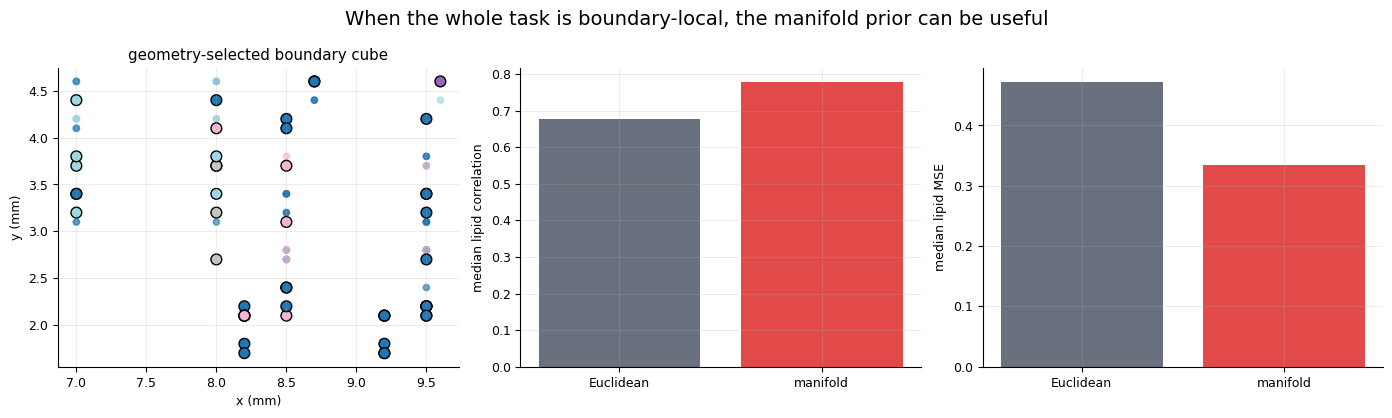

Euclidean: ell=0.5, median corr=0.678, MSE=0.472
manifold:  ell=6.0, median corr=0.778, MSE=0.335
manifold wins 164/173 correlations and 169/173 MSEs


In [14]:
center=np.array([8.5,3.2,4.1]); cube=np.flatnonzero(np.all(np.abs(xa-center)<=1.5,axis=1)); X,Y=xa[cube],za[cube]
Vcube=np.asarray(eg['eigvec'][nd[cube]],float); rng=np.random.default_rng(19); q=rng.permutation(len(cube)); fit,val,test=q[:140],q[140:180],q[180:]
RIDGE=np.logspace(-3,1,9)
def gram_m(A,B,w):
    da=np.sum(A*A*w,1); db=np.sum(B*B*w,1); return (A*w)@B.T/np.sqrt(da[:,None]*db[None,:])
def lipid_corr(P,T): return np.array([corr(P[:,k],T[:,k]) for k in range(T.shape[1])])
results={}
for kind,ells0 in [('Euclidean',[.2,.3,.5,.8,1.2,2.]),('manifold',[.5,1.,2.,2.95,4.,6.])]:
    best=None
    for ell in ells0:
        if kind=='Euclidean': K=matern(cdist(X,X),1.5,ell)
        else:
            sw=(4/ell**2+np.clip(ev,0,None))**-2; sw/=sw.sum(); K=gram_m(Vcube,Vcube,sw)
        for lam in RIDGE:
            pv=K[np.ix_(val,fit)]@cho_solve(cho_factor(K[np.ix_(fit,fit)]+lam*np.eye(len(fit)),check_finite=False),Y[fit],check_finite=False)
            s=np.nanmedian(lipid_corr(pv,Y[val]))
            if best is None or s>best[0]: best=(s,ell,lam,K)
    _,ell,lam,K=best; pt=K[np.ix_(test,fit)]@cho_solve(cho_factor(K[np.ix_(fit,fit)]+lam*np.eye(len(fit)),check_finite=False),Y[fit],check_finite=False)
    results[kind]=(ell,lam,lipid_corr(pt,Y[test]),np.mean((pt-Y[test])**2,0))
re,rm=results['Euclidean'],results['manifold']; x=np.arange(2)
fig,axes=plt.subplots(1,3,figsize=(14,4.2))
axes[0].scatter(X[fit,0],X[fit,1],c=ra[cube][fit],s=20,cmap='tab20',alpha=.65,label='fit')
axes[0].scatter(X[test,0],X[test,1],c=ra[cube][test],s=60,cmap='tab20',edgecolor='black',label='test'); axes[0].set(title='geometry-selected boundary cube',xlabel='x (mm)',ylabel='y (mm)')
axes[1].bar(x,[np.median(re[2]),np.median(rm[2])],color=[C_E,C_M]); axes[1].set_xticks(x,['Euclidean','manifold']); axes[1].set_ylabel('median lipid correlation')
axes[2].bar(x,[np.median(re[3]),np.median(rm[3])],color=[C_E,C_M]); axes[2].set_xticks(x,['Euclidean','manifold']); axes[2].set_ylabel('median lipid MSE')
fig.suptitle('When the whole task is boundary-local, the manifold prior can be useful',fontsize=14); fig.tight_layout(); plt.show()
print(f"Euclidean: ell={re[0]}, median corr={np.median(re[2]):.3f}, MSE={np.median(re[3]):.3f}")
print(f"manifold:  ell={rm[0]}, median corr={np.median(rm[2]):.3f}, MSE={np.median(rm[3]):.3f}")
print(f"manifold wins {np.sum(rm[2]>re[2])}/{za.shape[1]} correlations and {np.sum(rm[3]<re[3])}/{za.shape[1]} MSEs")

## Conclusion

> The atlas manifold prior has genuine anatomical capacity: it assigns different covariance to equally close same-region and cross-region pairs. Cross-boundary pairs are common, but their boundary identity adds less than one percentage point of pair-covariance variance beyond distance. The prior advantage is therefore too weak relative to the dominant spatial problem to improve held-out-brain prediction. When the task is deliberately restricted to a dense, boundary-local interpolation problem, the manifold can win strongly—demonstrating potential while also explaining why that potential does not transfer to the global deployment setting.

Caveats: pair counts are dependent; the local cube experiment re-splits one held-out anchor pool and is not cross-subject validation; the kernel-prior curves assess representational capacity, not posterior predictions.